# Dependencies

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Options

In [2]:
pd.set_option("display.max_columns", None)

# Data load

In [3]:
DATA_PATH = Path("../data/data.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,BaseOfCode,BaseOfData,Characteristics,DllCharacteristics,Entropy,FileAlignment,FirstSeenDate,Identify,ImageBase,ImportedDlls,ImportedSymbols,Label,Machine,Magic,NumberOfRvaAndSizes,NumberOfSections,NumberOfSymbols,PE_TYPE,PointerToSymbolTable,SHA1,Size,SizeOfCode,SizeOfHeaders,SizeOfImage,SizeOfInitializedData,SizeOfOptionalHeader,SizeOfUninitializedData,TimeDateStamp
0,4096,69632,783,0,5.981249,512,1970-01-01,powerbasic/win 8.00,4194304,comdlg32.dll gdi32.dll kernel32.dll ole32.dll ...,printdlga getopenfilenamea getsavefilenamea bi...,0,332,267,16,5,0,267,0,b0068836a40e6a43c6b546fcb709237e5aa223d1,76288,64855,1024,86016,2560,224,1500,12345
1,4096,1851392,783,0,6.081747,512,1970-01-01,NaN,4194304,comctl32.dll comdlg32.dll gdi32.dll kernel32.d...,imagelist_add imagelist_addmasked imagelist_be...,0,332,267,16,6,0,267,0,5741708cd785f13b44267883e3f2fd2fa51fc23f,2558464,1843888,1024,2600960,500348,224,21476,0
2,4096,40960,783,0,5.586422,512,1970-01-01,NaN,4194304,comdlg32.dll kernel32.dll msvcrt.dll msvcrt.dl...,getopenfilenamea closehandle createfilea creat...,0,332,267,16,9,0,267,0,507fe5d8244f33d29d427468efca4ce406f23666,178688,33792,1024,33759232,177664,224,33557504,0
3,1359872,2138112,783,0,7.969464,512,1970-01-01,"upx 2.93 - 3.00 [lzma] -> markus oberhumer, la...",4194304,kernel32.dll advapi32.dll comdlg32.dll gdi32.d...,loadlibrarya getprocaddress virtualprotect vir...,0,332,267,16,3,0,267,0,e51a7811464be1acadf6e72ba3a66aba0da438cd,806816,778240,4096,2166784,28672,224,1355776,0
4,4096,40960,783,32768,7.999900,512,1970-01-01,NaN,4194304,advapi32.dll comctl32.dll gdi32.dll kernel32.d...,regclosekey regcreatekeyexa regdeletekeya regd...,0,332,267,16,7,0,267,0,0e046d9903c313ffeeb0d6392335437fe881b1f5,50689096,35840,1024,303104,38912,224,110080,0


# Shapes & Types

In [4]:
df.shape

(50181, 28)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50181 entries, 0 to 50180
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BaseOfCode               50181 non-null  int64  
 1   BaseOfData               50181 non-null  int64  
 2   Characteristics          50181 non-null  int64  
 3   DllCharacteristics       50181 non-null  int64  
 4   Entropy                  50181 non-null  float64
 5   FileAlignment            50181 non-null  int64  
 6   FirstSeenDate            50181 non-null  str    
 7   Identify                 35958 non-null  str    
 8   ImageBase                50181 non-null  int64  
 9   ImportedDlls             50181 non-null  str    
 10  ImportedSymbols          50181 non-null  str    
 11  Label                    50181 non-null  int64  
 12  Machine                  50181 non-null  int64  
 13  Magic                    50181 non-null  int64  
 14  NumberOfRvaAndSizes      50181 no

In [6]:
df.dtypes.value_counts()

int64      22
str         5
float64     1
Name: count, dtype: int64

In [7]:
df.describe()

,BaseOfCode,BaseOfData,Characteristics,DllCharacteristics,Entropy,FileAlignment,ImageBase,Label,Machine,Magic,NumberOfRvaAndSizes,NumberOfSections,NumberOfSymbols,PE_TYPE,PointerToSymbolTable,Size,SizeOfCode,SizeOfHeaders,SizeOfImage,SizeOfInitializedData,SizeOfOptionalHeader,SizeOfUninitializedData,TimeDateStamp
count,5.018100e+04,5.018100e+04,50181.000000,50181.000000,50181.000000,50181.000000,5.018100e+04,50181.000000,50181.000000,50181.0,5.018100e+04,50181.000000,5.018100e+04,50181.0,5.018100e+04,5.018100e+04,5.018100e+04,50181.000000,5.018100e+04,5.018100e+04,50181.0,5.018100e+04,5.018100e+04
mean,1.724954e+05,8.834009e+05,18939.747016,10238.381080,6.694522,823.511050,1.636863e+08,0.579203,332.078874,267.0,5.118296e+05,5.724537,1.791587e+05,267.0,5.513845e+05,6.895724e+06,6.789796e+05,1595.302286,2.476806e+06,1.556195e+06,224.0,1.728905e+05,1.223333e+09
std,3.721744e+06,7.145701e+06,16567.684820,15085.745309,1.145355,1012.754781,4.065986e+08,0.493692,3.074768,0.0,2.615821e+07,2.512842,2.246279e+07,0.0,3.389692e+07,5.724471e+07,1.572283e+06,1263.993734,1.775206e+07,4.401886e+07,0.0,3.730825e+06,2.872506e+08
min,0.000000e+00,0.000000e+00,2.000000,0.000000,0.011174,32.000000,6.553600e+04,0.000000,332.000000,267.0,1.100000e+01,1.000000,0.000000e+00,267.0,0.000000e+00,2.560000e+03,0.000000e+00,512.000000,2.944000e+03,0.000000e+00,224.0,0.000000e+00,0.000000e+00
25%,4.096000e+03,6.144000e+04,291.000000,0.000000,6.210294,512.000000,4.194304e+06,0.000000,332.000000,267.0,1.600000e+01,4.000000,0.000000e+00,267.0,0.000000e+00,1.408000e+05,5.324800e+04,1024.000000,1.433600e+05,1.331200e+04,224.0,0.000000e+00,1.191272e+09
50%,4.096000e+03,3.358720e+05,8450.000000,1.000000,6.615470,512.000000,4.194304e+06,1.000000,332.000000,267.0,1.600000e+01,5.000000,0.000000e+00,267.0,0.000000e+00,5.723040e+05,2.688000e+05,1024.000000,5.242880e+05,7.987200e+04,224.0,0.000000e+00,1.367470e+09
75%,4.096000e+03,7.823360e+05,33167.000000,32768.000000,7.850877,512.000000,1.093140e+08,1.000000,332.000000,267.0,1.600000e+01,8.000000,0.000000e+00,267.0,0.000000e+00,1.981952e+06,6.906880e+05,1024.000000,1.466368e+06,2.959360e+05,224.0,0.000000e+00,1.421637e+09
max,2.457108e+08,9.415107e+08,44430.000000,60708.000000,8.000000,8192.000000,3.212837e+09,1.000000,452.000000,267.0,2.033305e+09,28.000000,4.143873e+09,267.0,2.425393e+09,3.986104e+09,9.786982e+07,50176.000000,1.473761e+09,4.294804e+09,224.0,2.457068e+08,4.107316e+09


### Observations

Majority of data is numeric, 5 string columns will need to be investigated for encoding. Some columns appear to have no variance (Magic, PE_TYPE), investigate and potentially drop.

# Target Variable Information

In [8]:
df["Label"].value_counts(normalize=True)

Label
1    0.579203
0    0.420797
Name: proportion, dtype: float64

### Observations

All rows have labels, ~58-42 split between malware and goodware. 

# Evaluating String Columns for Encoding

In [9]:
def inspect_str_col(df, col, target="Label"):
    print(f"\n=== {col} ===")
    
    total = len(df)
    missing = df[col].isna().sum()
    unique = df[col].nunique(dropna=True)
    
    print(f"Missing: {missing} ({missing/total:.1%})")
    print(f"Unique (non-null): {unique}")
    
    # missing vs label
    if missing > 0:
        print("\nLabel mean by missingness:")
        print(df.groupby(df[col].isna())[target].mean())
    
    # top values
    print("\nTop values:")
    print(df[col].value_counts(dropna=True).head(10))
    
    # avg length
    avg_len = df[col].dropna().astype(str).str.len().mean()
    print(f"\nAvg string length: {avg_len:.1f}")


In [10]:
str_cols = df.select_dtypes(include="object").columns

for c in str_cols:
    inspect_str_col(df, c)



=== FirstSeenDate ===
Missing: 0 (0.0%)
Unique (non-null): 2340

Top values:
FirstSeenDate
2009-07-14    2628
2013-08-22    2621
2016-07-16    2058
2010-11-20    1419
1992-06-19    1346
2009-07-13     980
2016-06-10     458
2015-07-07     430
2009-12-05     425
2013-08-06     316
Name: count, dtype: int64

Avg string length: 10.0

=== Identify ===
Missing: 14223 (28.3%)
Unique (non-null): 241

Label mean by missingness:
Identify
False    0.673174
True     0.341630
Name: Label, dtype: float64

Top values:
Identify
microsoft visual c++ 8 vc8 -> microsoft corporation microsoft visual c++ v8.0 microsoft visual c++ 8                                                          4486
borland delphi 3.0 (???) borland delphi 4.0 borland delphi v3.0                                                                                               4406
microsoft visual c# / basic .net microsoft visual studio .net .net executable microsoft visual c# v7.0 / basic .net                                       

/tmp/ipykernel_13238/537521977.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


### Observations

##### FirstSeenDate

Timestamp data, can be encoded after parsing, year and month, potentially day, would not breakdown into too many features

##### Identify

Some missing data (28.3%), with 68% of that being goodware, potentially useful to the model, full encoding would be problematic as the strings are messy and inconsistent, missing vs present encoding?

##### ImportedDll's

Domain specific with high chance of signal, structured and easily encoded if not too many permutations

##### ImportedSymbols

Domain specific, potential for signal. While structured, string lengths are very long and may balloon into too many features, 

##### SHA1

Unique hash per row, low signal potential, would be best to drop.

# Missing Values

In [11]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Identify    14223
dtype: int64

### Observations

Only row with missing values is Identify, as previously noted, should not be dropped

# Duplication

In [12]:
df.duplicated().sum()

np.int64(2480)

In [13]:
df.duplicated().mean()

np.float64(0.049421095633805624)

In [14]:
feature_cols = [c for c in df.columns if c != "Label"]
dup_groups = df[df.duplicated(subset=feature_cols, keep=False)]
dup_groups.groupby(feature_cols)["Label"].nunique().value_counts()

Label
1    1763
Name: count, dtype: int64

### Observations

5% of rows are full duplicates, with no variance between their labels, safe to dedupe from train data. 

# No Variance Cols

In [15]:
nunique = df.nunique()
no_variance_cols = nunique[nunique <= 1]

no_variance_cols


Magic                   1
PE_TYPE                 1
SizeOfOptionalHeader    1
dtype: int64

### Observations

Three coloumns with no variance, should be removed as their is no benefit in keeping them. 

# Distribution

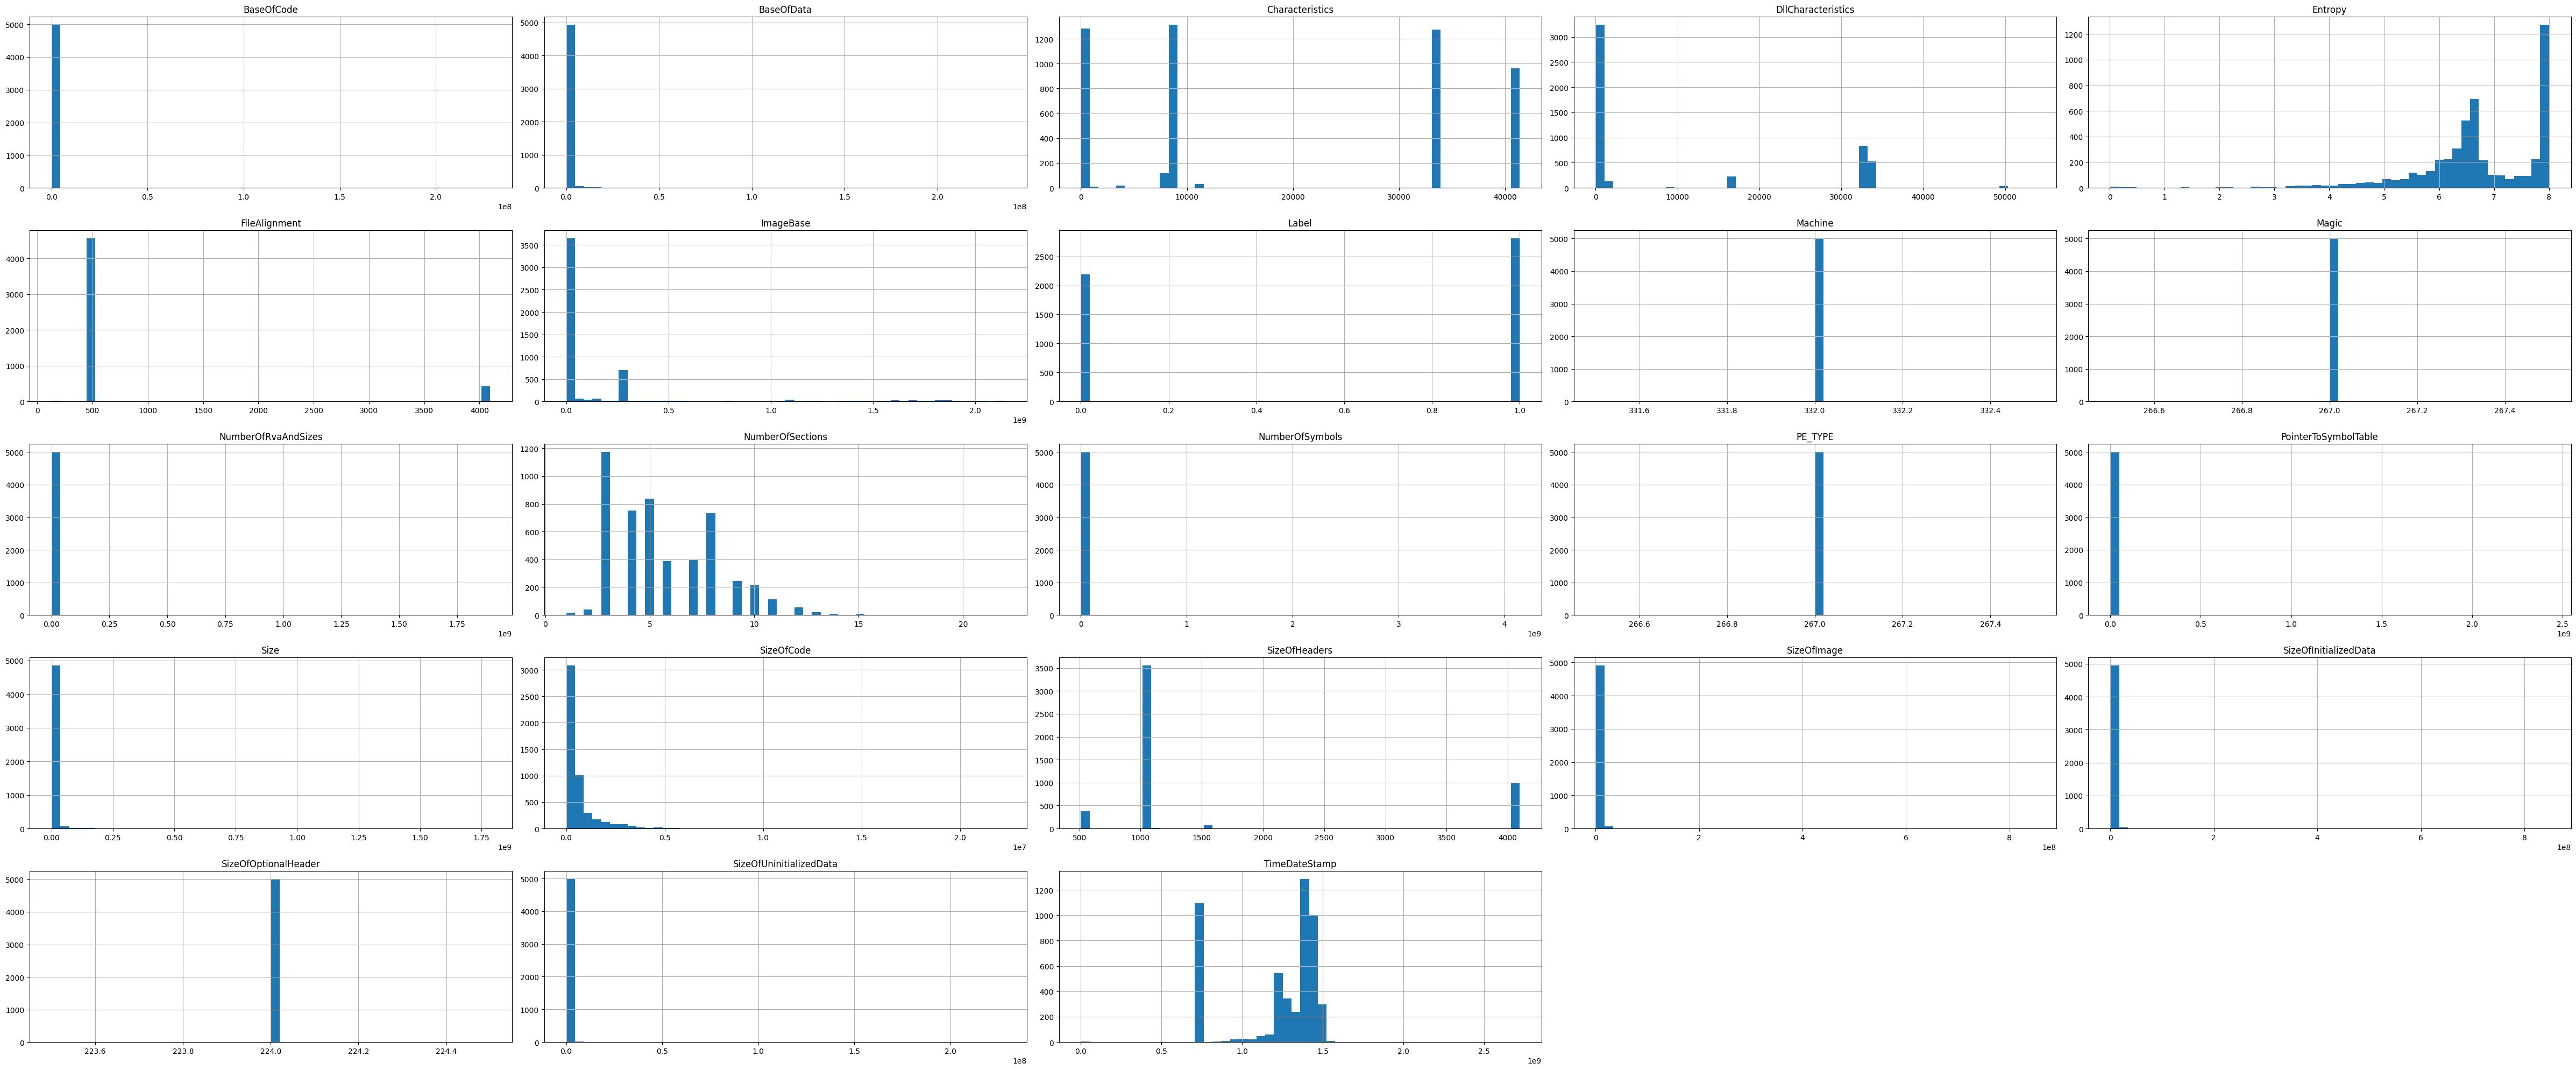

In [16]:
df.sample(5000).hist(bins=50, figsize=(48,20))
plt.tight_layout()

### Observations

Varied scales are noted, feature scaling will need to be applied. Some columns display very low varience other than those with no variance, should be kept as this could be a strong signal. 

# Correlation

In [17]:
corr = df.corr(numeric_only=True)
corr["Label"].sort_values(ascending=False)

Label                      1.000000
Characteristics            0.517163
NumberOfSections           0.292977
SizeOfCode                 0.190932
SizeOfHeaders              0.176875
Entropy                    0.168529
BaseOfData                 0.063045
SizeOfImage                0.040090
SizeOfUninitializedData    0.033685
BaseOfCode                 0.033410
NumberOfRvaAndSizes        0.016677
SizeOfInitializedData      0.015158
PointerToSymbolTable       0.013724
NumberOfSymbols            0.006798
Machine                   -0.030096
FileAlignment             -0.059408
Size                      -0.086217
TimeDateStamp             -0.226672
ImageBase                 -0.325238
DllCharacteristics        -0.363077
Magic                           NaN
PE_TYPE                         NaN
SizeOfOptionalHeader            NaN
Name: Label, dtype: float64

### Observations

Characteristics displays a strong correlation to the label, no features pose a very low correlation, as expected, features with no variance present no correlation, further supporting the decision to drop them. 